# Nutriscore 

To infer the nutritional value (like the Nutri-Score) of yogurts in the Open Food Facts (OFF) database, we can build a classification model. The goal is to predict the **Nutri-Score grade (A-E)** based on features like energy, sugar, fat, and fiber.

Since the OFF dataset is massive, we will use **DuckDB** for lightning-fast feature extraction and **Scikit-Learn** for the Machine Learning pipeline.

## 1. Data Extraction (DuckDB) - Cheese

We need to extract yogurts sold in Spain that actually have the nutritional values we need. We'll filter out rows with "None" or zero values for critical features to ensure the model learns correctly.

In [1]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

con = duckdb.connect(database=':memory:')
csv_path = 'en.openfoodfacts.org.products.csv.gz'

# 1. Extraction with Basic SQL Filtering
query = f"""
    SELECT 
        ('code_' || code) AS code,
        product_name,
        "energy-kcal_100g", "sugars_100g", "fat_100g", 
        "saturated-fat_100g", "proteins_100g", "salt_100g", 
        "fiber_100g", nutriscore_grade
    FROM read_csv_auto('{csv_path}', sep='\t', ignore_errors=True)
    WHERE (categories_en LIKE '%Cheese%' OR categories_en LIKE '%Queso%')
      AND countries_en LIKE '%Spain%'
      AND nutriscore_grade IS NOT NULL
"""
df = con.execute(query).df()

rows, cols = df.shape
print(f"Extracted {rows} products with {cols} features each.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Extracted 7821 products with 10 features each.


## 2. Data Cleaning

The Open Food Facts dump often contains "outliers" (e.g., someone typing 1000g of sugar in a 100g product). Before training a production model, it is vital to add a **clipping** step to remove values that are physically impossible.

To make your model robust, you must handle the "noise" inherent in crowdsourced data. In Open Food Facts, users occasionally enter 1000g of sugar for a 100g serving or confuse kJ with kcal.

**Why these cleaning steps matter**

1. **Logical Filtering:** Many products in the database have typos (e.g., salt listed as 50g instead of 0.5g). Since the sum of nutrients cannot exceed 100g, any value above that is "dirty data" and will confuse the model.
2. **Percentile Clipping:** By using the 99th percentile for calories, you remove the "junk" entries (like a yogurt accidentally listed with 10,000 calories) while keeping the actual variety of the market.
3. **Imputation (fillna):** In Open Food Facts, if a nutrient is 0, users often leave it blank. Replacing `NaN` with `0` for fiber or salt prevents the model from dropping rows that are actually valid.

In [2]:
# --- STEP: DATA CLEANING & CLIPPING ---

# A. Logical Constraints: Components cannot exceed 100g per 100g
nutrients = ["sugars_100g", "fat_100g", "saturated-fat_100g", "proteins_100g", "salt_100g", "fiber_100g"]
for col in nutrients:
    # Remove rows where a single nutrient is > 100 (impossible data)
    df = df[df[col] <= 100]
    # Fill missing values with 0 (common in OFF for fiber/salt)
    df[col] = df[col].fillna(0)

# B. Clipping Outliers (Statistical)
# Calories for yogurt rarely exceed 250 kcal/100g. We'll use the 99th percentile 
# to remove extreme outliers without losing real "indulgent" products.
upper_limit_kcal = df["energy-kcal_100g"].quantile(0.99)
df = df[df["energy-kcal_100g"] <= upper_limit_kcal]

# C. Target Cleaning
df = df[df['nutriscore_grade'].str.len() == 1]
df['nutriscore_grade'] = df['nutriscore_grade'].str.upper()

print(f"Cleaned dataset size: {len(df)} products")

Cleaned dataset size: 1375 products


## 2. The Machine Learning Pipeline

In this example, we use a **Random Forest Classifier**. This model is excellent for this task because it handles non-linear relationships well (e.g., how the balance of sugar vs. fiber affects the final score).

In [3]:
# --- STEP: MODEL TRAINING ---

feature_cols = [
    "energy-kcal_100g", "sugars_100g", "fat_100g",
    "saturated-fat_100g", "proteins_100g", "salt_100g",
    "fiber_100g"
]

X = df[feature_cols]
y = df['nutriscore_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"Refined Model Accuracy: {accuracy_score(y_test, model.predict(X_test)):.2%}")

Refined Model Accuracy: 89.09%


In [4]:
# Descargar listado de productos y códigos

products_codes = df[["code", "product_name"]].drop_duplicates()

products_codes.to_csv("productos_codigos_cheese.csv", index=False)

products_codes.head(20)

,code,product_name
9,code_0021000038565,Queso Tipo Parmesano Kraft Rallado
11,code_0021000612239,cream cheese
17,code_0036514237687,New York Extra Sharp Cheddar Cheese
20,code_0072820171239,Queso blanco
21,code_0075925303703,Gouda cheese stick
24,code_0081086101690,Queso tierno light
25,code_0091155144534,Queso cotija molido cheese shaker tripack
26,code_0093936521305,Fromage Camembert Danois 50%
52,code_05214830,Silver Decors (nonpareils)-cake Mate
58,code_0628250985870,Parmigie


## 3. Making an Inference (Prediction)

Now that the model is trained, you can feed it the nutritional data of a "new" yogurt to see what its Nutri-Score would be.

In [5]:
# Example: A Greek Yogurt (approximate values)
# Order: energy, sugars, fat, sat-fat, proteins, salt, fiber

# 1. Define your new yogurt data
new_cheese_data = [[400, 0.5, 33.0, 21.0, 25.0, 1.8, 0.0]]

# 2. Convert it to a DataFrame using the columns from your original X
new_cheese_df = pd.DataFrame(new_cheese_data, columns=X.columns)

# 3. Predict without warnings
prediction = model.predict(new_cheese_df)
print(f"The inferred Nutri-Score is: {prediction[0]}")

The inferred Nutri-Score is: D


## 4. Visualizing Feature Importance

You can run this to see what actually drives the Nutri-Score in your Spanish yogurt dataset:

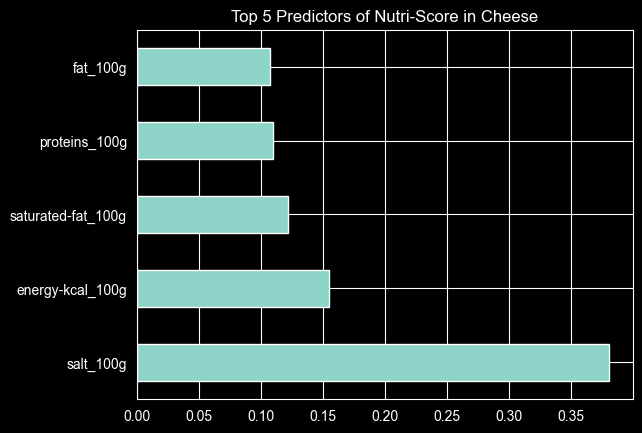

In [6]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh')
plt.title("Top 5 Predictors of Nutri-Score in Cheese")
plt.show()

## 5. Explaining

Using **SHAP (SHapley Additive exPlanations)** is the gold standard for "opening the black box" of Machine Learning. It tells you exactly **why** the model predicted a "C" instead of an "A" for a specific yogurt.

In the context of Open Food Facts, SHAP will show you, for example, how much the "Sugar" value pushed the score towards a worse grade.

Since we used a `RandomForestClassifier`, we will use the `TreeExplainer`.

In [7]:
import shap

# 1. Initialize the SHAP Explainer
# We use a sample of the training data to speed up calculation
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP values for the test set
# This might take a minute depending on the size of X_test
shap_values = explainer.shap_values(X_test)

# NOTE: For multi-class (A, B, C, D, E), shap_values is a list of arrays.
# shap_values[0] corresponds to class 'A', shap_values[1] to 'B', etc.
# Check model.classes_ to be sure of the order.
print(f"Model classes order: {model.classes_}")

Model classes order: ['A' 'B' 'C' 'D' 'E']


### 5.1 Visualizing the Explanations

#### A. The Global View (Summary Plot)

This shows which features are the most important across **all** yogurts.

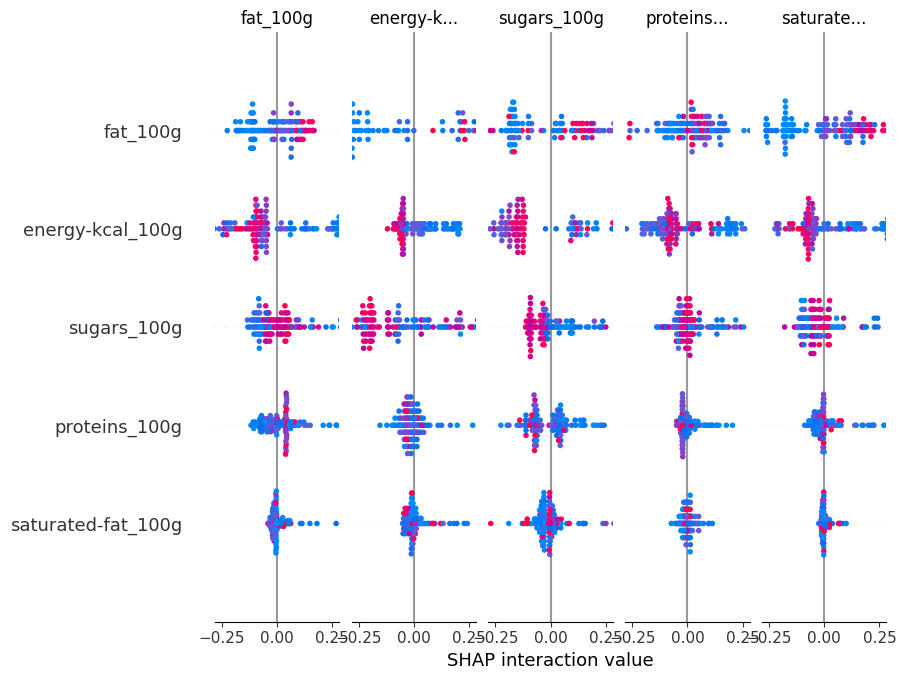

In [7]:
shap.summary_plot(shap_values, X_test, class_names=model.classes_)

The `summary_plot` is the "big picture" of your model. It combines **feature importance** (which nutrients matter) with **feature effects** (how those nutrients change the score).

#### A.1. Anatomy of the Standard Summary Plot (Dot Plot)

When you run `shap.summary_plot(shap_values[class_idx], X_test)`, you see a chart where every single dot represents a product (a yogurt) from your test set.

* **Vertical Axis (Y-axis):** Features are ranked by importance. The nutrient at the top (usually **Sugars** or **Energy** for Nutri-Score) has the biggest impact on the model's decision.
* **Horizontal Axis (X-axis):** This is the **SHAP Value**.
* **Positive SHAP (Right side):** The feature is *increasing* the probability of the predicted grade.
* **Negative SHAP (Left side):** The feature is *decreasing* the probability.


* **Color (Feature Value):**
* **Red:** High value of the nutrient (e.g., lots of sugar).
* **Blue:** Low value of the nutrient (e.g., zero fiber).

#### A.2. How to "Read" the Dots

The magic happens when you combine color and position. Let's look at **Sugars** in a plot for **Grade E (Unhealthy)**:

* **Red dots on the right:** High sugar (red) leads to a high SHAP value (right), meaning **high sugar strongly predicts a Grade E**.
* **Blue dots on the left:** Low sugar (blue) leads to a negative SHAP value (left), meaning **low sugar makes it almost impossible for the yogurt to be a Grade E**.

If you look at **Proteins** for **Grade A (Healthy)**:

* You might see **Red dots on the right**. This tells you that higher protein content pushes the yogurt towards an **A** grade.

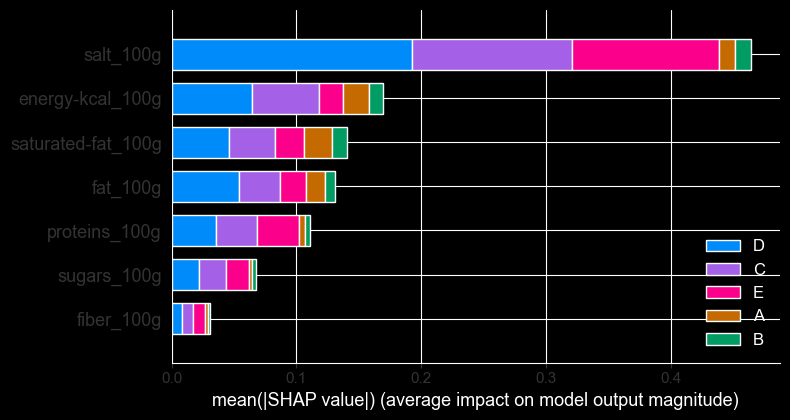

In [8]:
# This will show a stacked bar chart with different colors for A, B, C, D, E
shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=model.classes_)

#### A.3. The Stacked Bar Version

If you use `plot_type="bar"`, the dots disappear, and you get a clean bar chart. This is used for two things:

1. **Global Importance:** It shows the average impact magnitude ($mean(|SHAP|)$). It tells you *which* features the model relies on most, but loses the "direction" (doesn't tell you if high sugar is good or bad).
2. **Multiclass Comparison:** If you pass the entire `shap_values` list, it shows a stacked bar where colors represent different grades (A, B, C, D, E). This allows you to see, for example, that fiber is very important for distinguishing **A from B**, but irrelevant for distinguishing **D from E**.

---

#### A.4. What can you learn about Spanish Yogurts?

By looking at this plot, you can discover non-obvious patterns in the Open Food Facts data:

* **Overlap (Vertical Clumps):** If you see a thick clump of dots, many products share similar nutritional profiles.
* **Outliers (Lone Dots):** A red dot far to the right might represent a "sugar bomb"—a yogurt with extreme values that the model identifies immediately.
* **Feature Interaction:** If red and blue dots are mixed together on the same side, it suggests that the nutrient's effect depends on *another* nutrient (e.g., sugar matters, but its effect is different if the fat content is also high).

#### A.5 Summary Table: Interpretations

| Feature Position | Color | Interpretation |
| --- | --- | --- |
| Right Side (+) | **Red** | High values of this nutrient **promote** this grade. |
| Left Side (-) | **Red** | High values of this nutrient **prevent** this grade. |
| Right Side (+) | **Blue** | Low values of this nutrient **promote** this grade. |
| Left Side (-) | **Blue** | Low values of this nutrient **prevent** this grade. |

#### B. Waterfall plot (Manual Way)

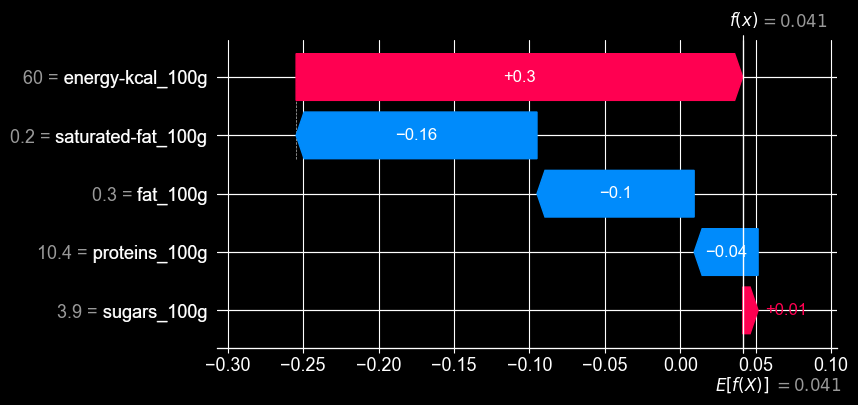

In [9]:
# index 0 is 'A', 4 is 'E'
target_class = 0 
sample_idx = 0

# Manually create the Explanation object required by the waterfall plot
exp = shap.Explanation(
    values=shap_values[target_class][sample_idx], 
    base_values=explainer.expected_value[target_class], 
    data=X_test.iloc[sample_idx], 
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(exp)

#### B.1. The Components of the Waterfall

When you call `shap.plots.waterfall(exp)`, the plot starts at the bottom and builds upward to the final prediction.

#### **A. The Base Value ($E[f(x)]$ or `base_values`)**

* **Where it is:** At the very bottom of the plot.
* **What it means:** This is the "starting point." It represents the average probability of a yogurt being the chosen grade (e.g., Grade 'A') across the entire dataset.
* **In your code:** You passed this as `explainer.expected_value[target_class]`. If the base value is 0.20, it means that, without knowing anything about this specific yogurt, the model assumes there is a 20% chance it's an 'A'.

#### **B. The Final Prediction ($f(x)$)**

* **Where it is:** At the very top of the plot.
* **What it means:** This is the model’s final calculated probability for that specific yogurt. If $f(x) = 0.85$, the model is 85% sure this product is Grade 'A'.

#### **C. The "Steps" (The Nutrients)**

* Each row represents a specific nutrient (e.g., `sugars_100g = 4.5`).
* The length of the horizontal bar is the **SHAP value**—the exact "weight" that nutrient added or subtracted from the probability.

#### B.2. Reading the Colors and Directions

The waterfall plot is a tug-of-war between "Healthy" and "Unhealthy" components:

* **Red Bars (Arrows pointing Right / Positive):** These nutrients **increased** the probability of the grade you are analyzing.
* *Example:* If you are analyzing Grade 'A', a red bar for `proteins_100g` means the high protein content is "helping" the yogurt be an 'A'.


* **Blue Bars (Arrows pointing Left / Negative):** These nutrients **decreased** the probability.
* *Example:* If you are analyzing Grade 'A', a blue bar for `sugars_100g` means the sugar content is "hurting" its chances of being an 'A'.

#### B.3. Why the "Manual Way" is structured like that

When you built the `exp` object, you mapped four critical pieces of information that the plot needs to render correctly:

1. **`values`**: The "length" of the bars.
2. **`base_values`**: The starting point of the waterfall.
3. **`data`**: The actual numbers (e.g., 12.5g of sugar) that appear next to the feature names on the left.
4. **`feature_names`**: The labels (so you see "sugars_100g" instead of just "Feature 1").

#### B.4. An Example Interpretation

Imagine you are explaining why a specific Spanish yogurt got a **Grade 'A'**:

1. **Base Value:** Starts at **0.25** (Average chance of 'A').
2. **Fiber (+0.15, Red):** It has high fiber, which pushes the probability up.
3. **Sugars (-0.10, Blue):** It has some sugar, which pulls the probability down.
4. **Saturated Fat (+0.20, Red):** It is a 0% fat yogurt, so the *low* fat content pushes the probability up significantly.
5. **Final $f(x)$:** The waterfall ends at **0.50**.

The model says: *"This yogurt has a 50% probability of being Grade A. Its strongest feature is the low saturated fat, but its sugar content is preventing it from being an even 'clearer' A."*

#### B.5 Pro-Tip for the Manual Way:

If you are analyzing **Grade 'E'** (the worst grade), the colors switch roles in your head:

* A **Red bar** for sugar now means: *"This sugar is making the product worse (more likely to be E)."*
* A **Blue bar** for protein means: *"This protein is trying to save the product from being an E."*

In [10]:
print("Filas finales:", df.shape[0])
print("Columnas:", df.shape[1])

print(df['nutriscore_grade'].value_counts().sort_index())

df.describe()

Filas finales: 1375
Columnas: 10
nutriscore_grade
A     54
B     28
C    227
D    886
E    180
Name: count, dtype: int64


,energy-kcal_100g,sugars_100g,fat_100g,saturated-fat_100g,proteins_100g,salt_100g,fiber_100g
count,1375.000000,1375.000000,1375.000000,1375.000000,1375.000000,1375.000000,1375.000000
mean,301.303884,1.688046,23.282725,15.359739,18.698818,1.542419,0.446046
std,100.644750,3.492275,9.833394,7.114282,8.429098,1.878748,1.517245
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,246.833333,0.000000,17.000000,10.500000,12.000000,0.960000,0.000000
50%,316.000000,0.500000,25.000000,17.000000,20.000000,1.485167,0.000000
75%,376.000000,2.000000,30.000000,20.000000,25.000000,1.800000,0.100000
max,511.000000,43.000000,50.400000,37.700000,46.670000,47.500000,24.100000


              precision    recall  f1-score   support

           A       0.80      0.89      0.84         9
           B       0.33      0.25      0.29         4
           C       0.83      0.85      0.84        41
           D       0.90      0.97      0.93       176
           E       0.97      0.69      0.81        45

    accuracy                           0.89       275
   macro avg       0.77      0.73      0.74       275
weighted avg       0.89      0.89      0.89       275



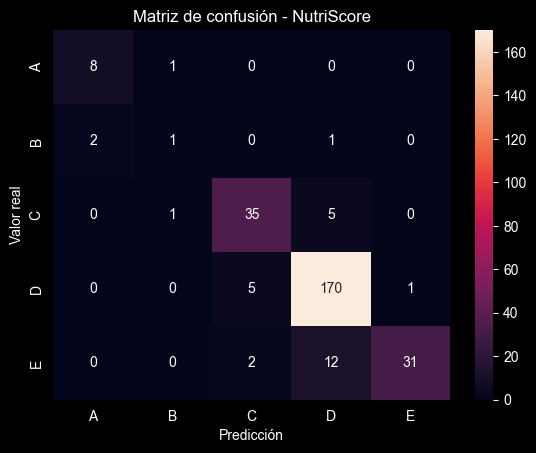

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - NutriScore")
plt.show()